<a href="https://colab.research.google.com/github/PioPio31/AnaliticaDeDatos_Equipo1/blob/main/Practica4_U2/Practica4_PaolaIbarra23111420.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Curso: modelos de aprendizaje**

**UNIDAD 2**


---

*   NOMBRE: Paola Ibarra Ordaz
*   NO CONTROL: 23111420



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/analitica datos"
os.chdir(DIR)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,StandardScaler, OrdinalEncoder,FunctionTransformer

# Librerías para la canalización
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Librerías para la regresión
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline #Se repite
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, confusion_matrix, precision_score,recall_score,accuracy_score
from sklearn.decomposition import PCA

from sklearn.preprocessing import PolynomialFeatures

---

## **<font color=" #895cf9">Explica brevemente el uso de las librerias del segmento de codigo anterior, haciendo uso de la siguiente tabla</font>**


| Librería | Explicación |
|----------|-------------|
| **import pandas (pd)** | Se utiliza para trabajar con los datos en forma de tablas. Permite cargar, organizar, consultar y modificar la información del conjunto de datos de una manera más sencilla. |
| **import numpy (np)** | Se utiliza para realizar operaciones numéricas y trabajar con arreglos de datos. Es una librería muy utilizada como base para otros procesos de análisis y procesamiento de datos. |
| **import matplotlib (plt)** | Permite crear gráficas para representar visualmente los datos y facilitar su análisis. |
| **import seaborn (sns)** | Se utiliza para generar gráficas estadísticas de una forma más sencilla y con una presentación más adecuada para analizar relaciones y distribuciones entre los datos. |
| **from sklearn.impute import SimpleImputer** | Se utiliza para tratar los valores faltantes del conjunto de datos. Permite reemplazarlos utilizando diferentes estrategias, como la media, mediana o un valor determinado. |
| **from sklearn.preprocessing import MinMaxScaler** | Se utiliza para escalar los valores de las variables a un rango específico, normalmente entre 0 y 1. Esto ayuda a que las variables tengan una escala comparable. |
| **from sklearn.preprocessing import OneHotEncoder** | Convierte variables categóricas en varias columnas con valores binarios (0 y 1), permitiendo que puedan ser utilizadas por los modelos de aprendizaje automático. |
| **from sklearn.preprocessing import StandardScaler** | Estandariza los datos para que tengan una media cercana a 0 y una desviación estándar de 1. Es útil cuando las variables tienen escalas muy diferentes. |
| **from sklearn.preprocessing import OrdinalEncoder** | Convierte categorías de texto en valores numéricos siguiendo un orden establecido. Es útil cuando las categorías tienen una relación ordinal. |
| **from sklearn.preprocessing import FunctionTransformer** | Permite aplicar una función personalizada a los datos durante el proceso de transformación. |
| **from sklearn.compose import ColumnTransformer** | Permite aplicar diferentes transformaciones a distintas columnas del conjunto de datos. Por ejemplo, se puede escalar una columna numérica y codificar una categórica dentro del mismo proceso. |
| **from sklearn.compose import make_column_selector** | Facilita la selección automática de columnas según sus características, por ejemplo, seleccionando solamente las columnas numéricas o las categóricas. |
| **from sklearn.pipeline import make_pipeline** | Permite unir varias etapas de procesamiento y modelado en una sola secuencia. De esta manera, las transformaciones y el modelo pueden ejecutarse de forma ordenada. |
| **from sklearn.linear_model import LinearRegression** | Implementa un modelo de regresión lineal, utilizado para predecir una variable numérica a partir de una o más variables de entrada. |
| **from sklearn.linear_model import LogisticRegression** | Implementa un modelo de regresión logística, utilizado principalmente para problemas de clasificación, donde se busca determinar a qué categoría pertenece un dato. |
| **from sklearn.metrics import mean_squared_error** | Calcula el error cuadrático medio entre los valores reales y los valores que predice el modelo. Sirve para evaluar qué tan alejadas están las predicciones de los valores reales. |
| **from sklearn.metrics import r2_score** | Calcula el coeficiente de determinación R², que permite conocer qué tan bien el modelo explica la variación de los valores de la variable que se quiere predecir. |
| **from sklearn.metrics import confusion_matrix** | Genera una matriz de confusión que permite comparar las clases reales con las clases predichas por un modelo de clasificación. |
| **from sklearn.metrics import precision_score** | Calcula la precisión del modelo de clasificación, es decir, qué proporción de las predicciones positivas realizadas fueron correctas. |
| **from sklearn.metrics import recall_score** | Mide qué proporción de los casos positivos reales fueron identificados correctamente por el modelo. |
| **from sklearn.metrics import accuracy_score** | Calcula la exactitud del modelo, indicando qué proporción de todas las predicciones fueron correctas. |
| **from sklearn.decomposition import PCA** | Corresponde al Análisis de Componentes Principales. Se utiliza para reducir la cantidad de variables, conservando la mayor cantidad posible de información de los datos. |
| **from sklearn.preprocessing import PolynomialFeatures** | Genera características polinómicas a partir de las variables existentes. Esto permite que un modelo pueda representar relaciones más complejas que una relación lineal simple. |


### Referencias bibliográficas

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 51–56. https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Waskom, M. L. (2021). Seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021






---

In [4]:
#lectura del .csv con pandas
data_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/analitica datos/data.csv')
data_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# **Parte 1**. EDA

Haz que el `id` sea el índice del dataframe y efectúa una exploración inicial de los datos a través de:

In [5]:
#utilice funcion .set_index()
#Guarde los cambios con inplace=True
data_df.set_index('id',inplace=True)

#-----------------------------------------------------
#Escriba su codigo

#-----------------------------------------------------

#-----------------------------------------------------


In [6]:
data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820




1a) Estadísticas descriptivas para todas las variables del dataframe.

In [7]:
#.describe para variables Numericas
#-----------------------------------------------------
data_df.describe()
#-----------------------------------------------------

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [9]:
#.describe() para variable categoricas
#-----------------------------------------------------
data_df.describe(include='object')
#-----------------------------------------------------

,diagnosis
count,569
unique,2
top,B
freq,357


1b) Valores únicos por variable para identificar posibles variables categóricas.

In [10]:
# Se hace una lista de variables numéricas y otra de categóricas.

#-----------------------------------------------------
num_cols = data_df.select_dtypes(include=np.number).columns.tolist() #para variables numericas
cat_cols = data_df.select_dtypes(exclude=np.number).columns.tolist() #para variables Categoricas
#-----------------------------------------------------

In [11]:
# Recuento de cada categoría única en las variables categóricas
data_df[cat_cols].nunique()

,0
diagnosis,2


In [12]:
# Recuento de cada categoría única en las variables categóricas
data_df[cat_cols].value_counts()

,count
diagnosis,
B,357
M,212


1c) Búsqueda de valores faltantes.

In [13]:
#Explica cada linea de codigo
print('Número valores faltantes: ') #Imprime un mensaje
for col in data_df.columns: # Realiza un ciclo que se va a repetir según el numero de columnas
  valor=sum(data_df[col].isna()) #Suma los valores nulos de la columna actual
  porcentaje=data_df[col].isna().mean()*100 #Calcula el porcentaje de valores nulos
  print('{}:{}: porcentaje :{}'.format(col,valor,porcentaje)) #Imprime el nombre de la columna, el valor y el porcentaje de nulos

Número valores faltantes: 
diagnosis:0: porcentaje :0.0
radius_mean:0: porcentaje :0.0
texture_mean:0: porcentaje :0.0
perimeter_mean:0: porcentaje :0.0
area_mean:0: porcentaje :0.0
smoothness_mean:0: porcentaje :0.0
compactness_mean:0: porcentaje :0.0
concavity_mean:0: porcentaje :0.0
concave points_mean:0: porcentaje :0.0
symmetry_mean:0: porcentaje :0.0
fractal_dimension_mean:0: porcentaje :0.0
radius_se:0: porcentaje :0.0
texture_se:0: porcentaje :0.0
perimeter_se:0: porcentaje :0.0
area_se:0: porcentaje :0.0
smoothness_se:0: porcentaje :0.0
compactness_se:0: porcentaje :0.0
concavity_se:0: porcentaje :0.0
concave points_se:0: porcentaje :0.0
symmetry_se:0: porcentaje :0.0
fractal_dimension_se:0: porcentaje :0.0
radius_worst:0: porcentaje :0.0
texture_worst:0: porcentaje :0.0
perimeter_worst:0: porcentaje :0.0
area_worst:0: porcentaje :0.0
smoothness_worst:0: porcentaje :0.0
compactness_worst:0: porcentaje :0.0
concavity_worst:0: porcentaje :0.0
concave points_worst:0: porcentaje :

1d) Diagrama de barras para determinar la frecuencia de los diagnósticos (cantidad de observaciones con resultado benigno y maligno)

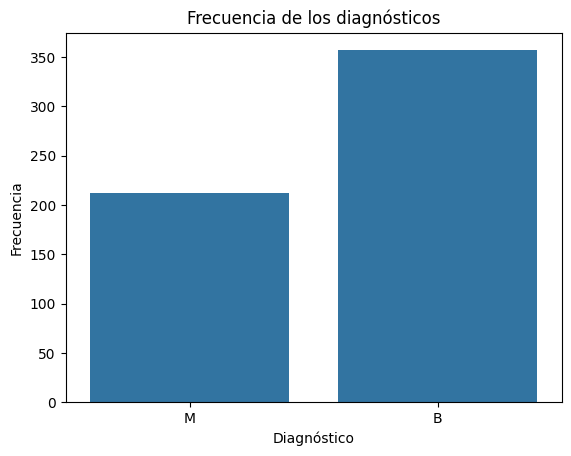

In [14]:
#utilice sns.countplot()
#-----------------------------------------------------
sns.countplot(data=data_df, x='diagnosis')
plt.title('Frecuencia de los diagnósticos')
plt.xlabel('Diagnóstico')
plt.ylabel('Frecuencia')
plt.show()
#-----------------------------------------------------

2. Como hay tres valores relacionados con la misma característica (`mean`, `se` y `worst`) es muy probable que exista multicolinealidad en el conjunto.

La multicolinealidad en regresión es una condición que ocurre cuando algunas variables predictoras están fuertemente correlacionadas entre sí, de tal manera que si se incluyen simultáneamente en un modelo, impiden explicar de manera correcta el efecto que cada una tiene sobre la variable respuesta. Existen muchas formas de analizar si hay colinealidad en los modelos, una de ellas es el alto coeficiente de correlación entre variables.

Para observar este efecto, elabora un mapa de calor que cuantifique la correlación de las variables numéricas en el dataframe.

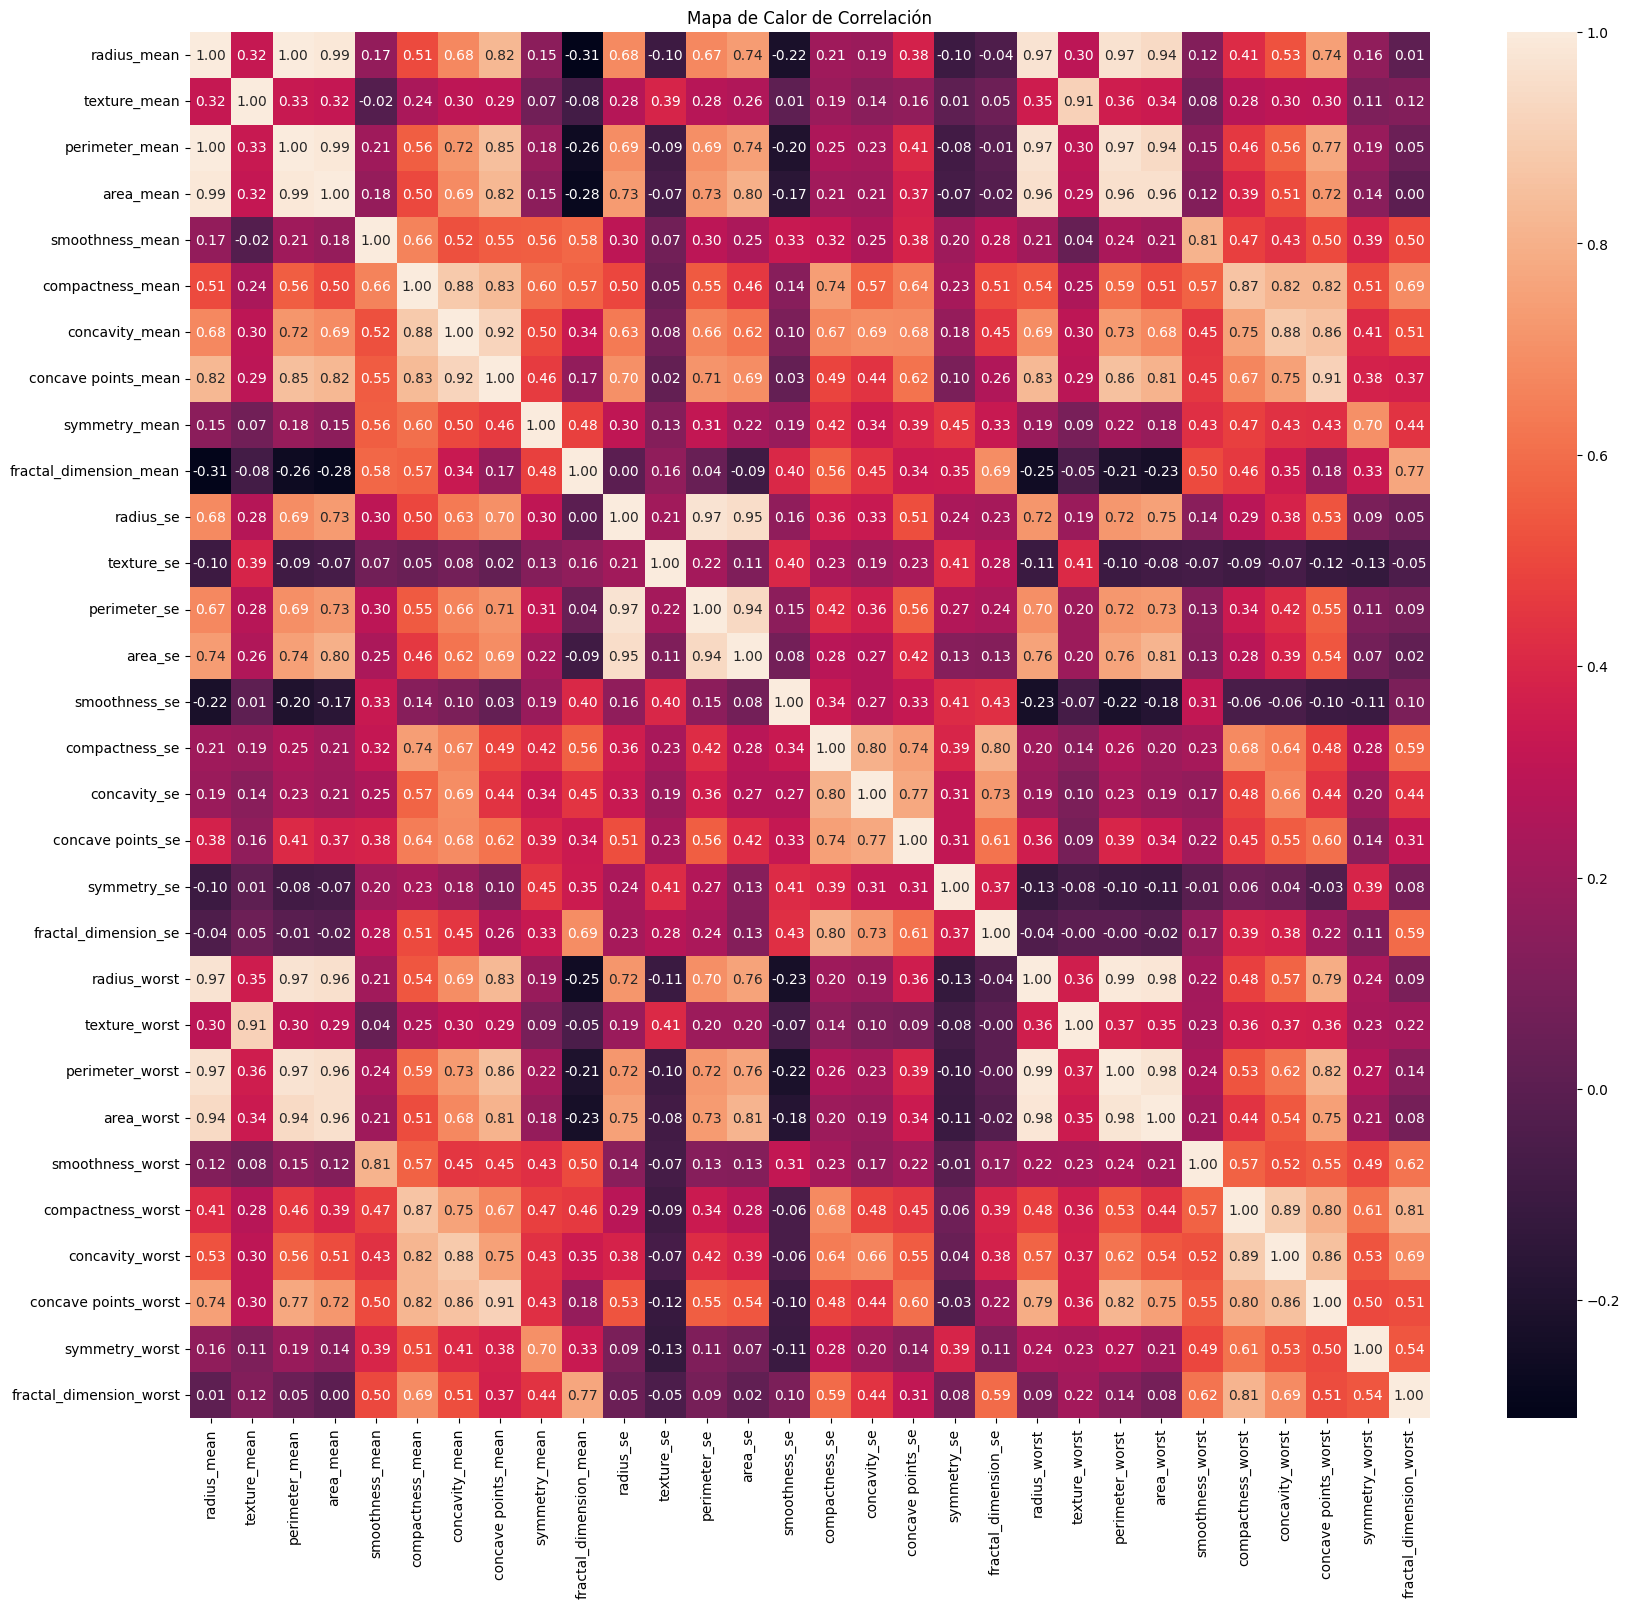

In [18]:
numeric_df = data_df.select_dtypes(include=[float, int])

#-----------------------------------------------------
plt.figure(figsize=(20, 18))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')
plt.title('Mapa de Calor de Correlación')
plt.show()
#-----------------------------------------------------

Si te fijas en los valores de correlación entre las variables `_mean` y `_worst` es evidente la multicolinearidad.

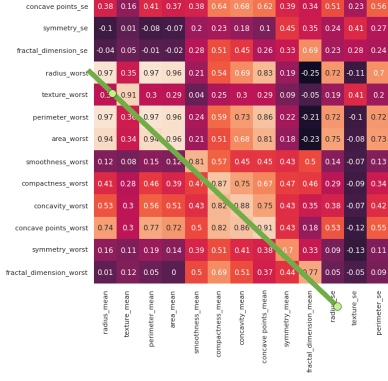

Por ejemplo, la columna `radius_mean` tiene una correlación de 0.97 con la columna `radius_worst`. Esto es algo inevitable, porque las columnas "peores" son esencialmente solo un subconjunto de las columnas "medias".

Para solucionar el problema numérico de la multicolinealidad, tradicionalmente se recurre a eliminar variables o efectuar análisis de componentes principales (PCA) con las `X`’s y usar los componentes como variables independientes en un modelo final.

Conduciremos esta actividad en esos dos sentidos.


# **Parte 2**. Modelo con eliminación de variables altamente correlacionadas  

Elimina las variables altamente correlacionadas:

3a) Ahora que sabes que las variables `_mean` y `_worst` tienen correlación alta, hay que quitar del dataframe un conjunto. Borra las columnas `_worst`.

In [20]:
#-----------------------------------------------------
#Elimine TODAS las columnas _worst
columnas_worst = [col for col in data_df.columns if '_worst' in col]
#-----------------------------------------------------

#para borrar las columnas _worst
new_data_df = data_df.drop(columns=columnas_worst)

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
new_data_df = pd.DataFrame(new_data_df)
new_data_df
#-----------------------------------------------------

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892


En las graficas de dispersion, los patrones lineales en los diagramas de dispersion se refieren a la relacion entre dos variables que sigue una tendencia aproximadamente en linea recta, ya sea en direccion ascendente o descentende

* **Patron lineal positivo**: Si la linea se inclina hacia arriba (de izquierda a derecha), indica que hay una relacion directa entre las variables: cuando la variable aumenta, la otra tambien lo hace, es decir, CORRELACION POSITIVA

* **Patron lineal negativo**: si la linea se incluna hacia abajo (de izquierda a derecha), indica quue cuando una variable aumenta, la otra disminuye, es decir, CORRELACION NEGATIVA

* **Patron lineal perfecto**, si los puntos siguen una linea recta perfecta, la relacion entre las variables es exactamente lineal, sin desviaciones.


3b. Entre las variables `_mean`, identifica patrones lineales con diagramas de dispersión usando:

    sns.pairplot(data=nuevo_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])



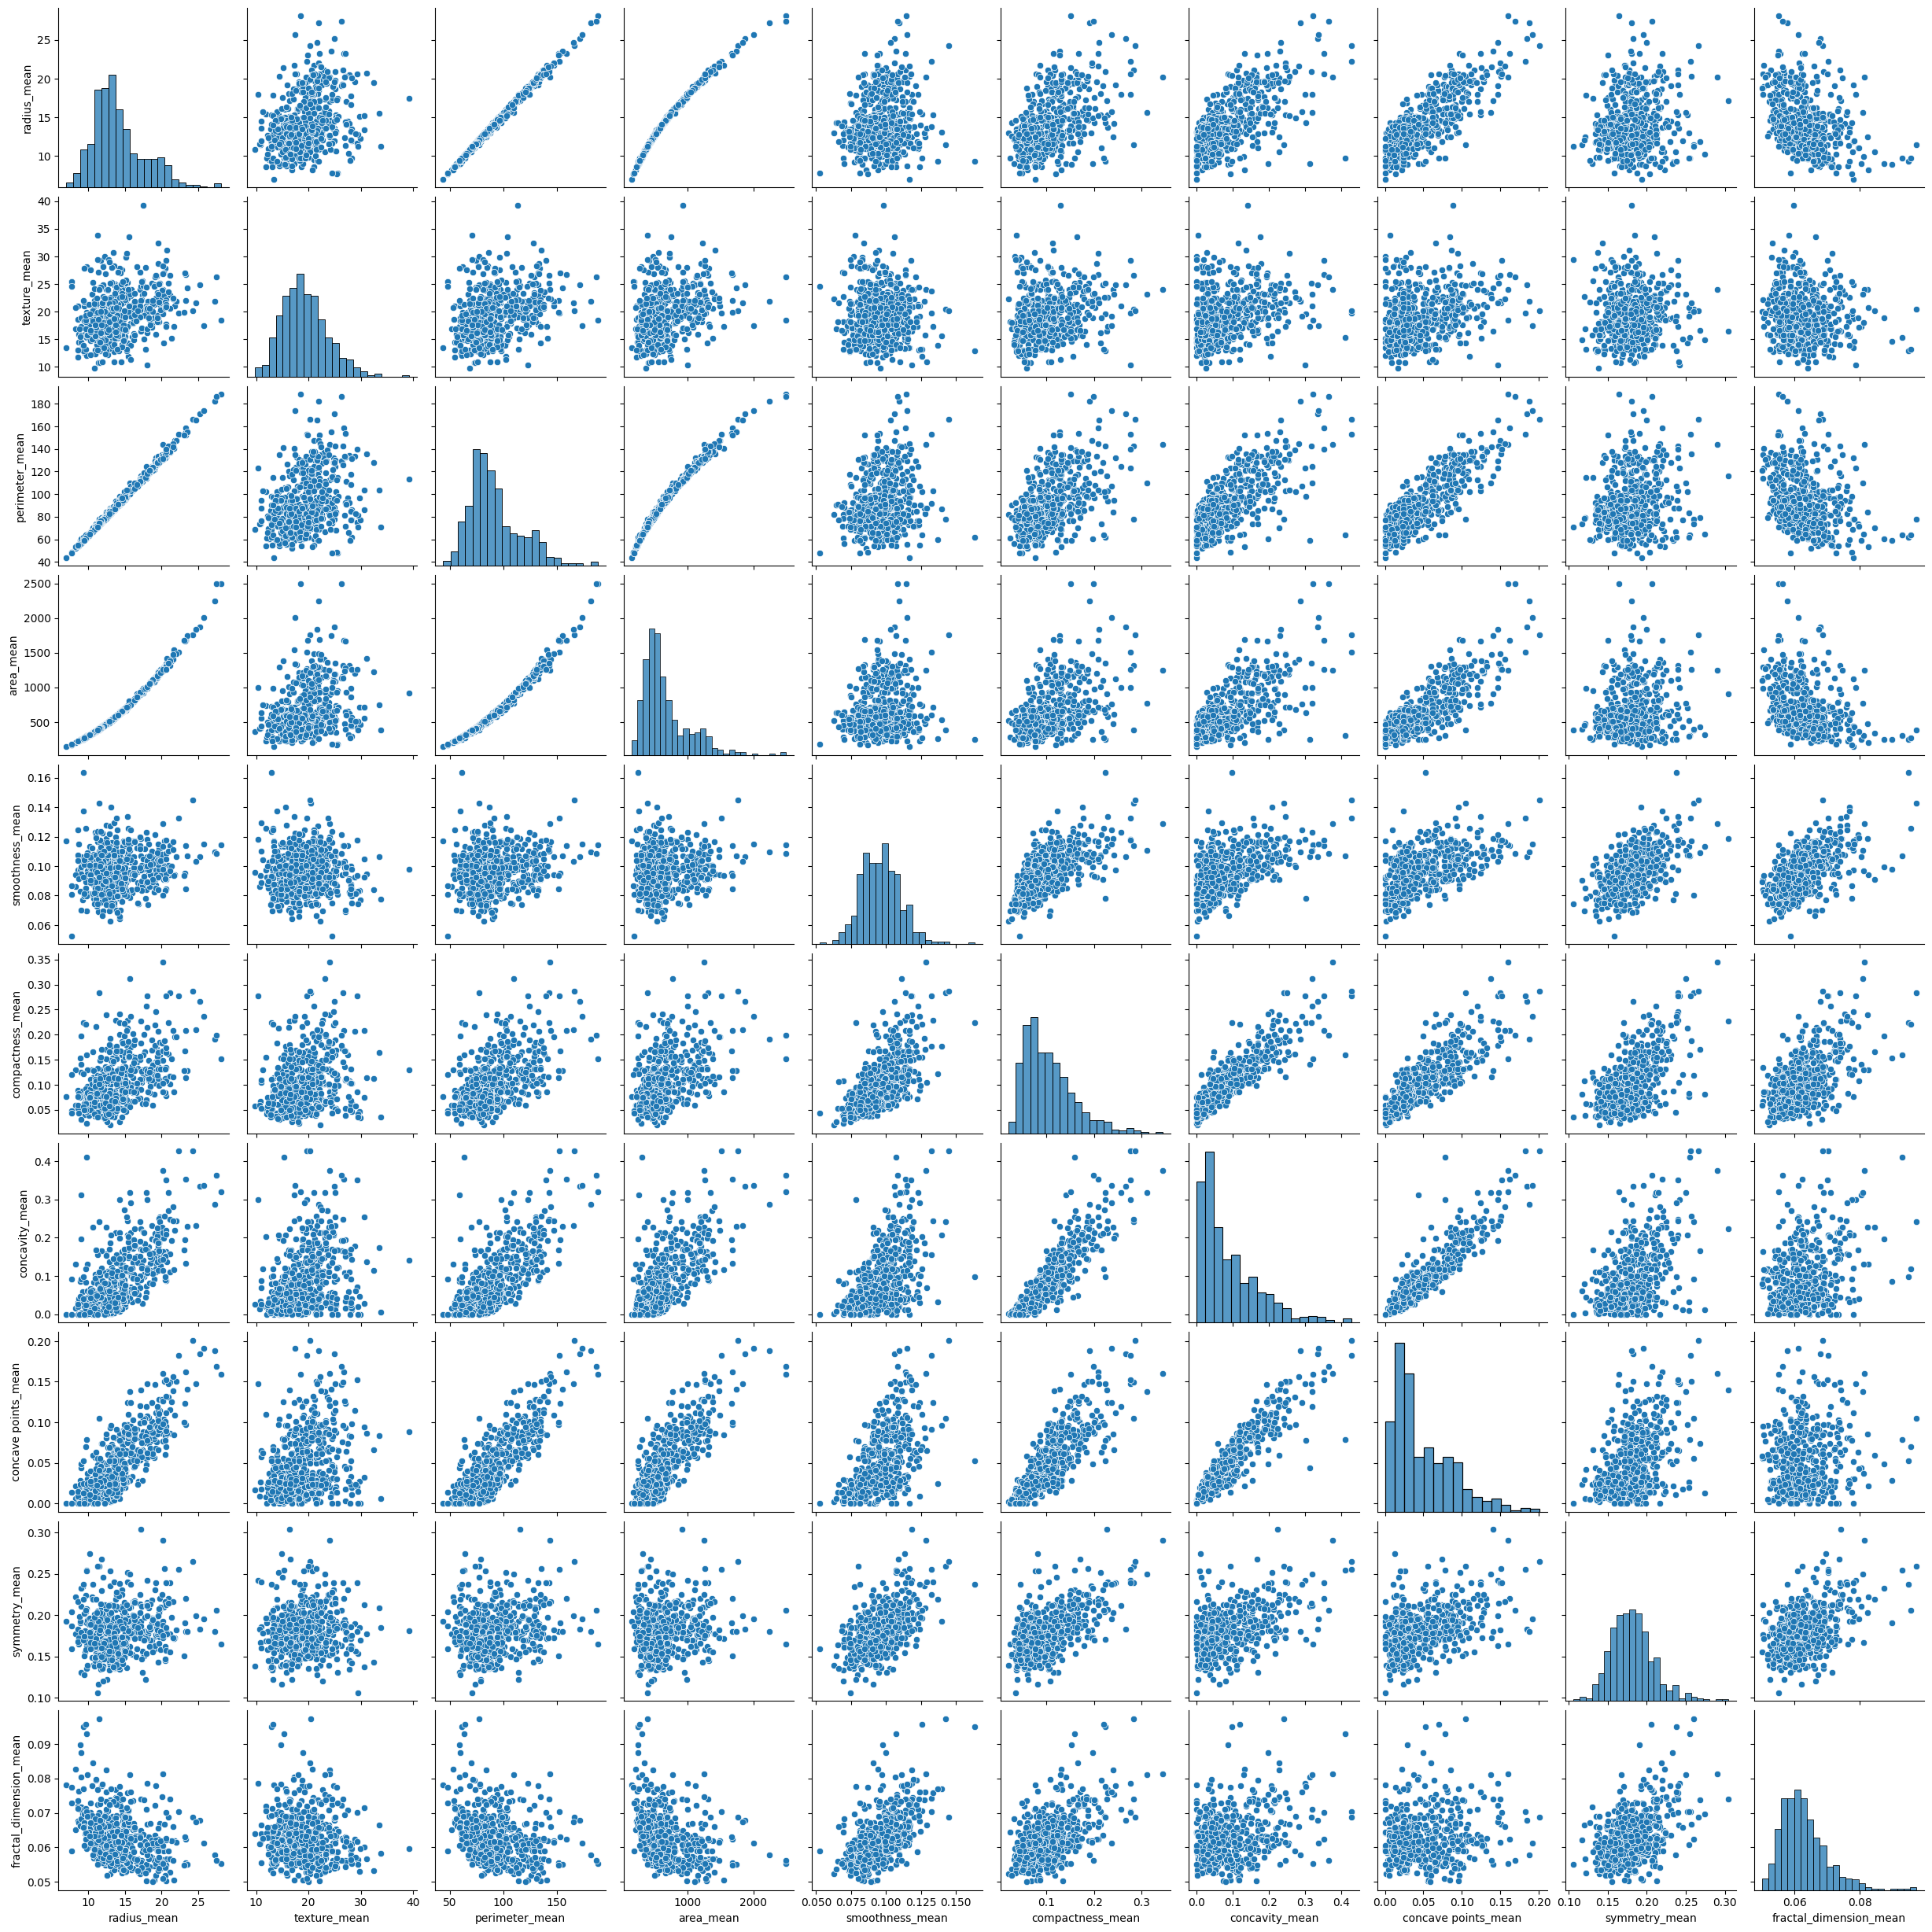

In [22]:
#-----------------------------------------------------
#Pega aqui el codigo sns.pairplot()
sns.pairplot(data=new_data_df[['radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean']])
#-----------------------------------------------------

De la matriz podrás observar relaciones lineales bastante evidentes entre:


*   `radius_mean`, `perimeter_mean` y `area_mean`
*   `compactness_mean`, `concavity_mean`, `concave_points_mean`

Sabemos que el perímetro y el área de un círculo, se calculan a partir del radio. Entonces, la relación entre las primeras tres variables es muy clara para nosotros.

3c) Elabora otro mapa de calor confirmar con los valores de correlación.


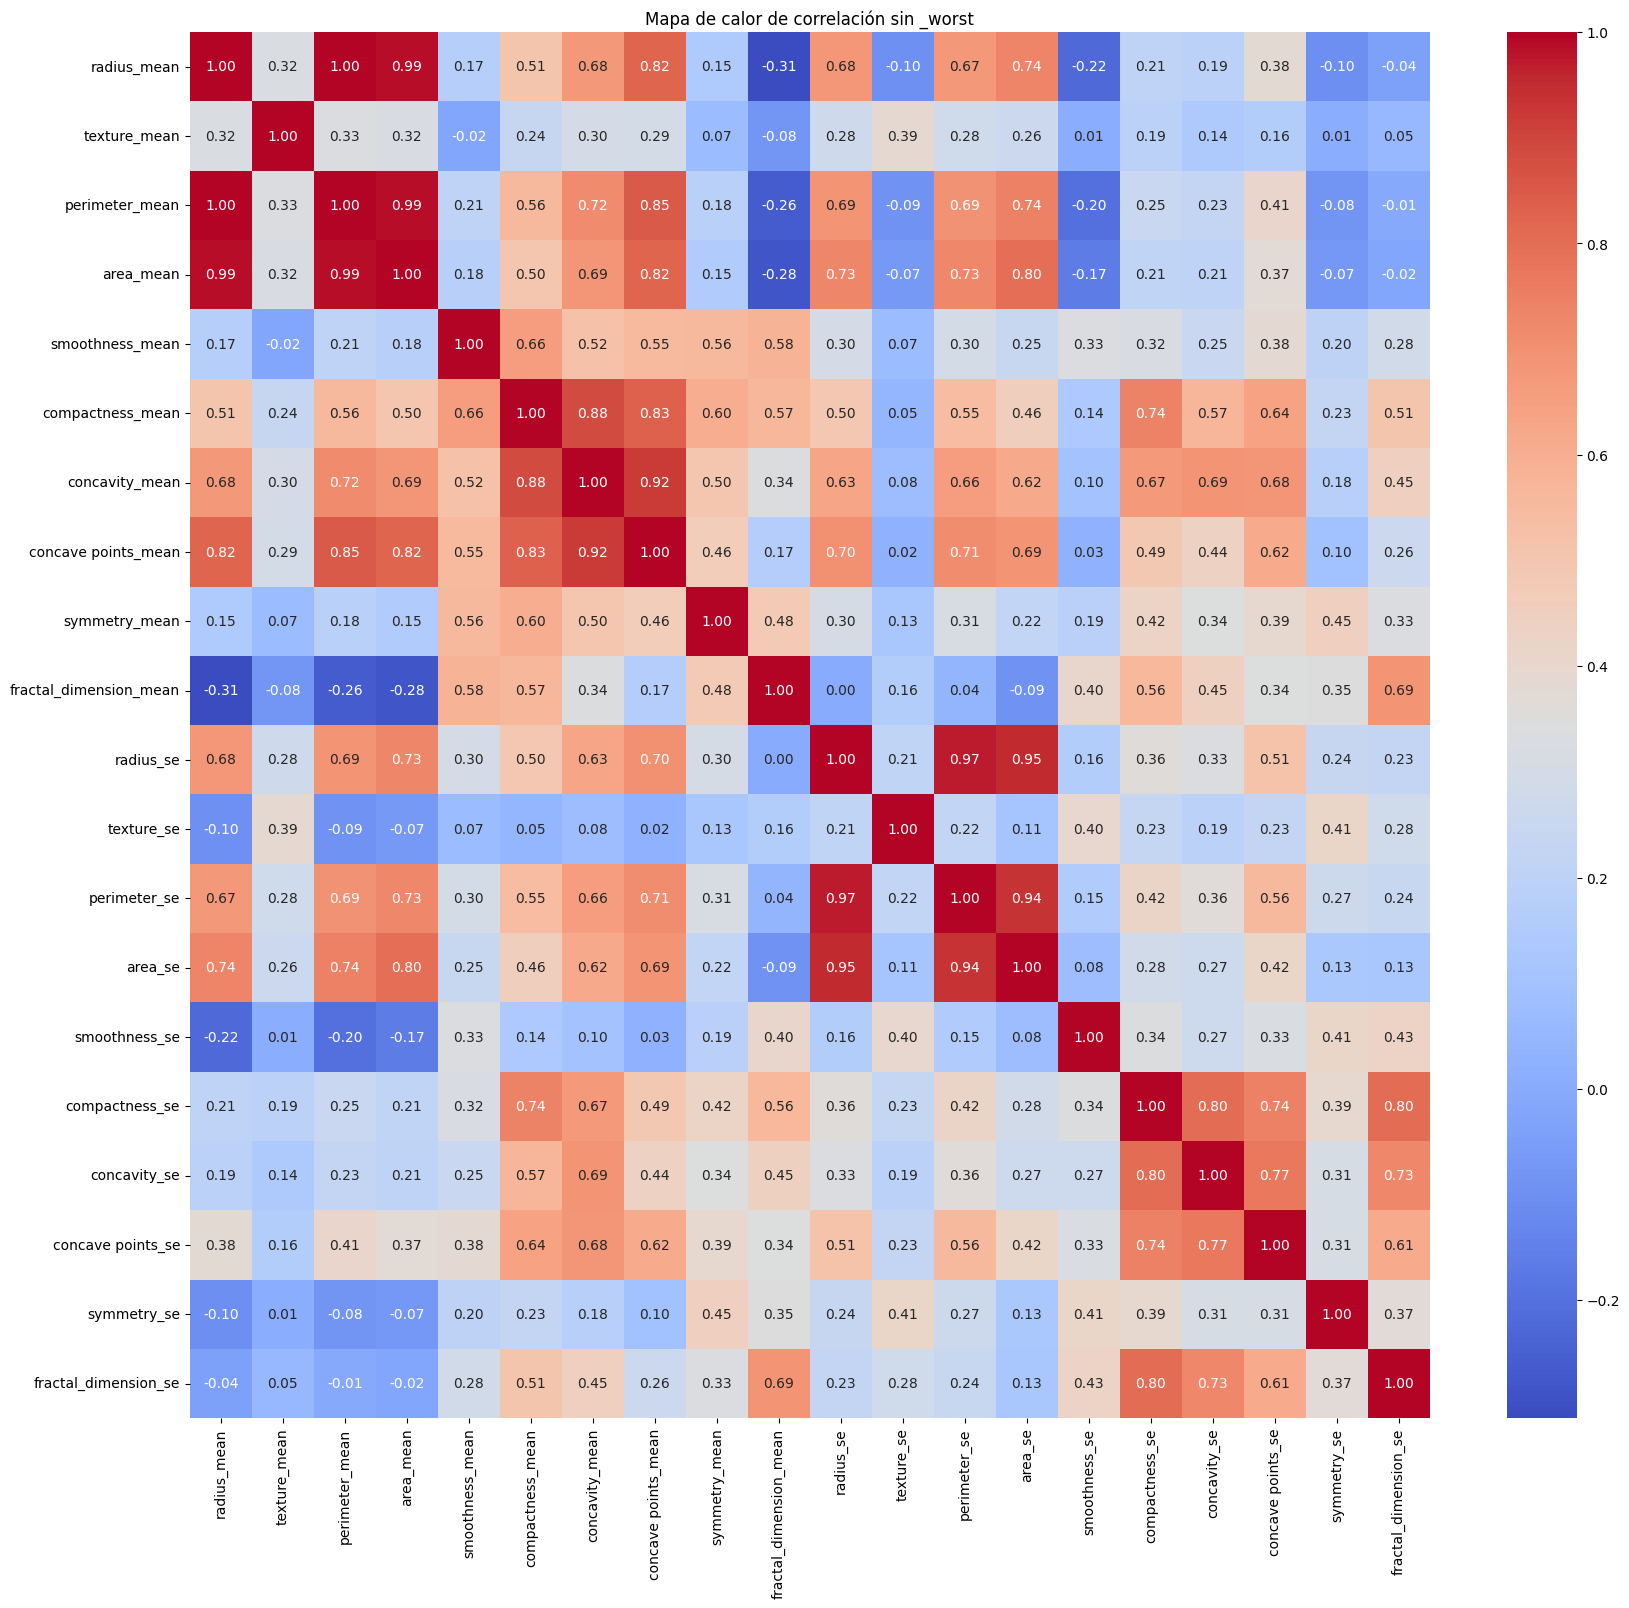

In [24]:
#-----------------------------------------------------
#Agrega codigo para el mapa de calor
numeric_df_nuevo = new_data_df.select_dtypes(include=np.number)
plt.figure(figsize=(20, 18))
sns.heatmap(numeric_df_nuevo.corr(),annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlación sin _worst')
plt.show()
#-----------------------------------------------------

3d) Después de observar los valores, nos quedaremos con sólo una variable de cada trío: `radius_mean` y `compactness_mean`. Elimina las restantes, no sólo del conjunto `_mean`, sino también de `_se`.

In [25]:

#-----------------------------------------------------
#escriba TODAS las columnas que seran eliminadas
columnas_a_eliminar=['perimeter_mean','area_mean','concavity_mean',
                     'concave points_mean','perimeter_se','area_se','concavity_se',
                     'concave points_se']
#-----------------------------------------------------

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
new_data_df= new_data_df.drop(columns=columnas_a_eliminar)
new_data_df
#-----------------------------------------------------


,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,
842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,0.11100,0.11590,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.01114,0.004239
926682,M,20.13,28.25,0.09780,0.10340,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.01898,0.002498
926954,M,16.60,28.08,0.08455,0.10230,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.01318,0.003892


Observa la distribución de las variables resultantes (deben ser 12, sin contar la columna de indice):

4a) Utilizando histogramas. Guarda en una variable (`skew_cols`) las que tengan marcado sesgo positivo. Para dar seguridad a tu selección, elige aquellas cuyo resultado de aplicar la función `skew()` sea mayor a 1.

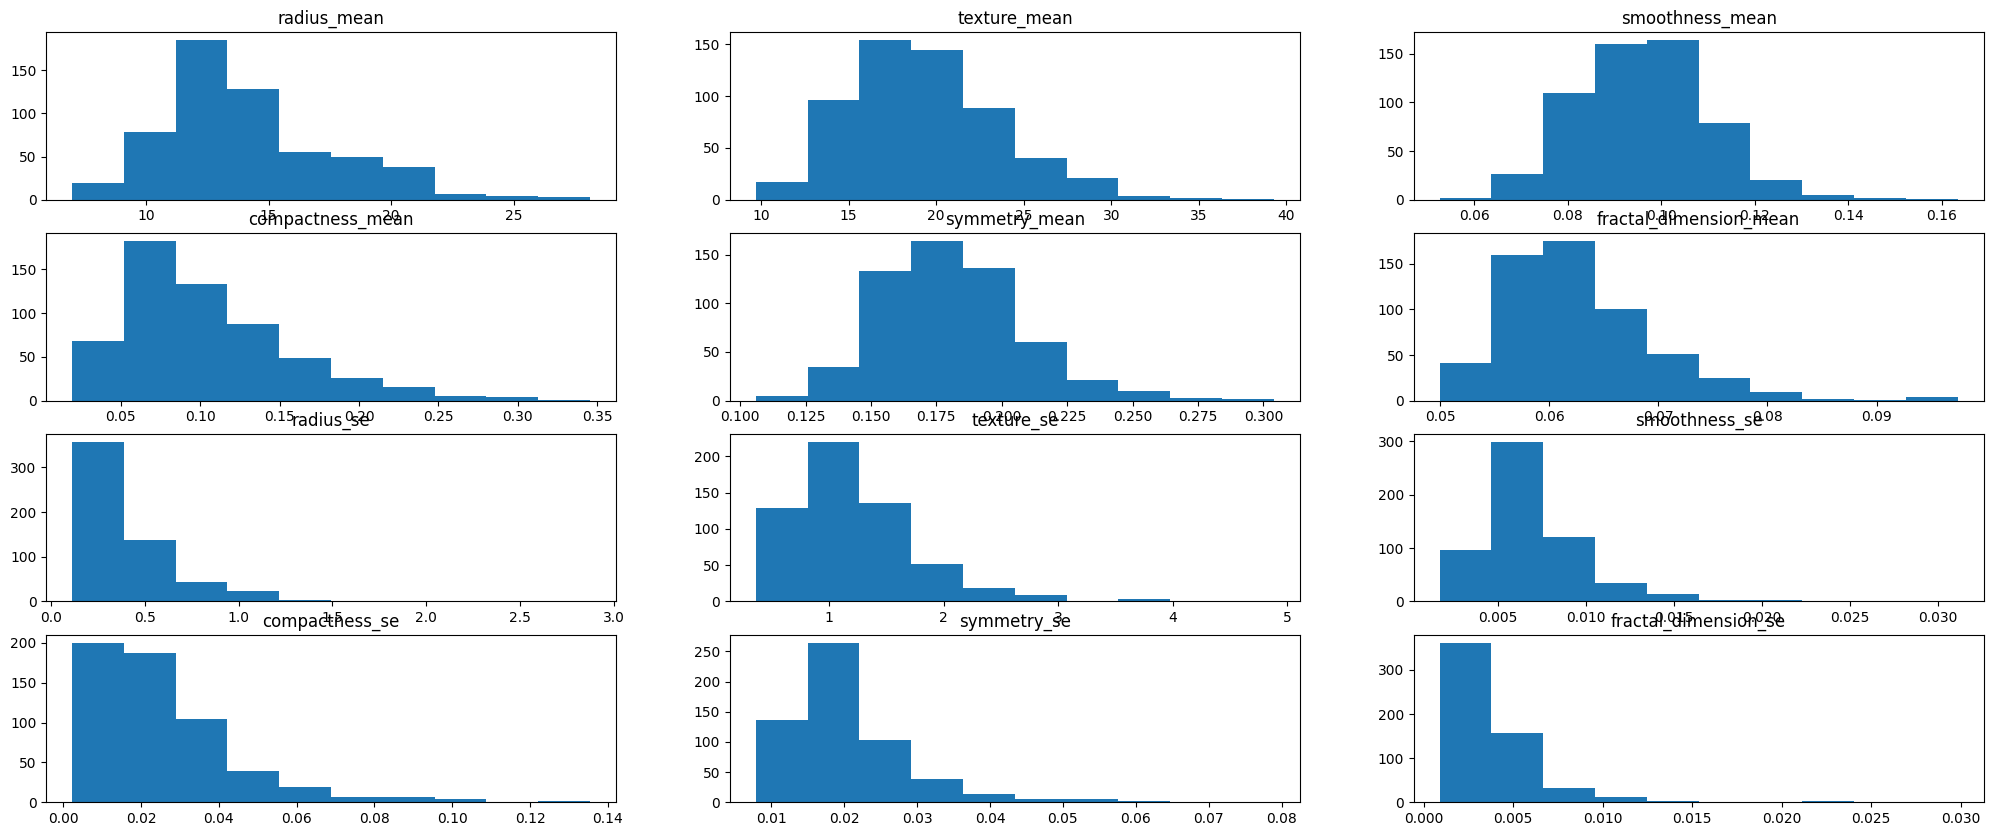

In [26]:
#EXPLICA CADA LINEA DE CODIGO
skew_cols_df=pd.DataFrame() #Se crea un DataFrame vacío para almacenar las columnas con sesgo positivo
#Se crea una figura y un arreglo de ejes para las gráficas. 4 filas, 3 columnas, tamaño 25x10
fig, axes =plt.subplots(4,3, figsize=(25,10)) #25 es el ancho, 10 altura   ---- 4,3 significa que seran  4 filas y 3 columnas
axes = axes.ravel() #ravel convierte la matriz de ejes en un array de 12 elementos
#Se obtiene una lista de los nombres de las columnas numéricas del DataFrame
num_cols = new_data_df.select_dtypes(include=np.number).columns.tolist()

#Se itera sobre cada columna numérica y su eje correspondiente
for col, ax in zip (num_cols, axes):
  ax.hist(new_data_df[col]) #Se realiza un histograma para la columna en su eje
  ax.set(title = f'{col}', xlabel=None)#El titulo del histograma se establece según la columna
  #Si el sesgo de la columna es mayor a 1 se añade al DataFrame skew_cols_df
  if new_data_df[col].skew()>1 : skew_cols_df[col] =new_data_df[col]

#Se guardan los nombres de las columnas con sesgo positivo en skew_cols
skew_cols = skew_cols_df.columns.values



In [27]:
skew_cols

array(['compactness_mean', 'fractal_dimension_mean', 'radius_se',
       'texture_se', 'smoothness_se', 'compactness_se', 'symmetry_se',
       'fractal_dimension_se'], dtype=object)

4b) Dibujando box plots de todas las variables. Guarda en una variable (`scale_cols`) aquellas que no se encuentren en el intervalo [0,1]


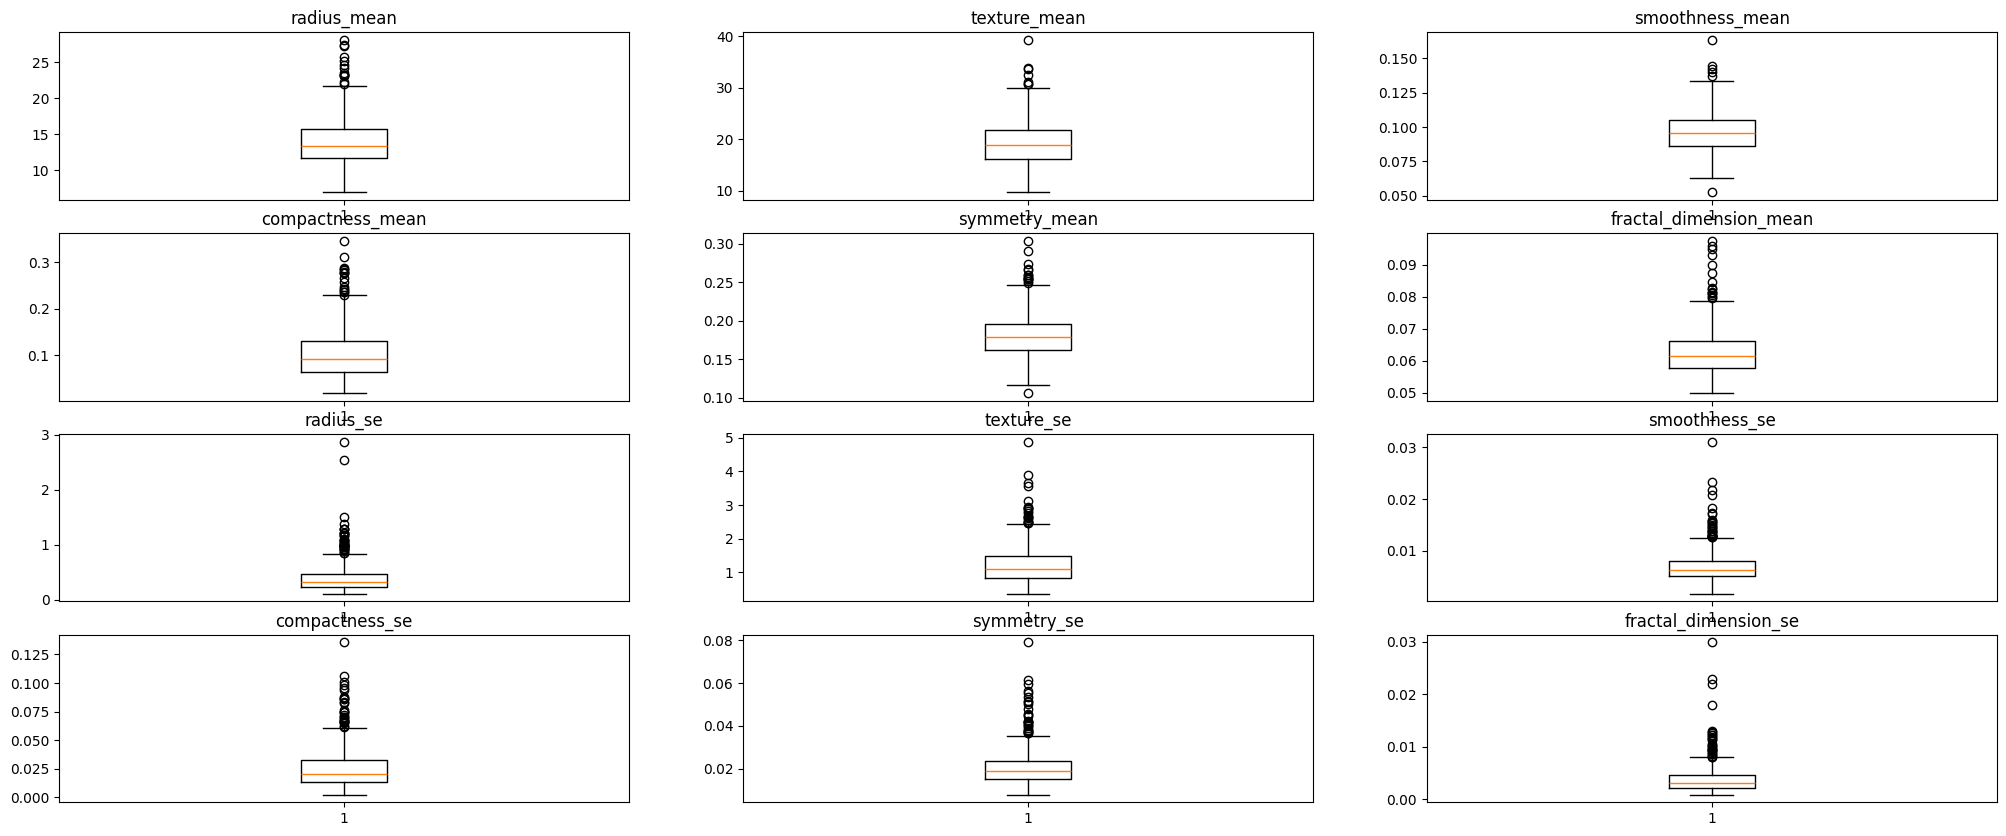

In [41]:
scale_cols_df=pd.DataFrame()
fig, axes = plt.subplots(4,3, figsize=(25,10))
axes = axes.ravel()

#-----------------------------------------------------
for col, ax in zip(new_data_df[num_cols], axes):

  ax.boxplot(new_data_df[col]) #COMPLETA LINEA DE CODIGO
  ax.set(title=f'{col}', xlabel=None)

  #COMPLETA EL IF
  if not (new_data_df[col].max() < 1 and new_data_df[col].min() > 0):
    scale_cols_df[col] = new_data_df[col]

    #DUDA
    #if not (new_data_df[col].max() < 1 and new_data_df[col].min() > 0):
    #scale_cols_df[col] = new_data_df[col]
#-----------------------------------------------------

scale_cols = scale_cols_df.columns.values



In [42]:
scale_cols

array(['radius_mean', 'texture_mean', 'radius_se', 'texture_se'],
      dtype=object)

Con todo el análisis anterior, estamos listos para generar un modelo *baseline* denominado `logr_model`. Para ello:

5a) Vuelve a leer el contenido del archivo, haz que el `id` sea el índice y separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`diagnosis`). Divide el conjunto en entrenamiento y prueba (80:20) considerando el parámetro `random_state` con el valor de 1.

In [43]:
data_df = pd.read_csv('data.csv')

#-----------------------------------------------------
#AGREGA LINEA DE CODIGO PARA CONVERTIR COLUMNA "ID" EN INDICE
data_df.set_index('id', inplace=True)

#-----------------------------------------------------

In [44]:
X = data_df.copy() #Se crea copia del df


#-----------------------------------------------------
#                                  COMPLETA CODIGO
# se elimina variable Categorica "diagnosis" de (X), debido a se sera utilizada como variable de salida (y)
#-----------------------------------------------------
#Especifique la columna que desea eliminar
#Utilice el parametro axis=1, permitira eliminar la columna
#Guarde los cambios agregando el parametro inplace=True

X.drop('diagnosis', axis=1, inplace=True) #Caracteristica / variable Entrada
#-----------------------------------------------------

#-----------------------------------------------------
y = data_df['diagnosis'] #Objetivo /Variable salida
#-----------------------------------------------------

In [45]:
#Libreria necesaria para realizar la particion del conjunto de datos
from sklearn.model_selection import train_test_split

# Se divide el conjunto en entrenamiento y prueba (80:20), es decir, 80% para Entrenamiento (train) y 20% para Prueba (test)
Xtrain, Xtest, ytrain, ytest = train_test_split(X,#variable entrada
                                                y,#variable salida o predictora
                                                train_size=0.8, # tamaño conjunto entrenamiento
                                                random_state=1) #para mantener mismo conjunto de datos

5b) Prepara un transformador, denominado `preprocessing`, para borrar las columnas altamente correlacionadas (las 18 variables que se determinaron en los ejercicios previos) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.

In [46]:
#EXPLIQUE CADA LINEA DE CODIGO
#Se define una lista con los nombres de las columnas a eliminar del modelo por alta correlación
columnas_a_eliminar=['radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst','perimeter_mean','area_mean','concavity_mean','concave points_mean','perimeter_se','area_se','concavity_se','concave points_se']
#Se crea un objeto ColumnTransformer para aplicar diferentes transformaciones a subconjuntos de columnas
preprocessing = ColumnTransformer([
    #Se define una transformación llamada num que aplicará la operación drop a las columnas en la lista
    ('num', 'drop', columnas_a_eliminar)]
   ,remainder='passthrough') #remainder asegura que todas las demás columnas no especificadas se mantengan


5c) Entrena el modelo `logr_model` con el transformador `preprocessing` y  regresión logística.

Como la salida `y` está en términos de las etiquetas `'B'` y `'M'`, en lugar de 0 y 1, para evaluar el modelo en el conjunto de prueba deberás especificar la clase positiva. En el caso de la matriz de confusión, indica el orden de las etiquetas con `labels=['B','M']`, porque `'B'` es la clase negativa (ésta se especifica primero) y `'M'` la positiva. Para las métricas de *recall* y *precision*, utiliza el parámetro `pos_label='M'`. Como *accuracy* ocupa la suma de ambas clases y el total de las observaciones, no requiere ninguna especificación. Si quisieras omitir estos parámetros, tendrías que sustituir `'B'` por 0 y `'M'` por 1, previo a la construcción del modelo.

In [47]:
#EXPLIQUE CADA LINEA DE CODIGO
#Se crea un pipeline que primero aplica el preprocesamiento y luego entrena un modelo de regresión logística
logr_model=make_pipeline(preprocessing, LogisticRegression())
logr_model.fit(Xtrain,ytrain) #Se entrena el pipeline con los datos de entrenamiento
predictions=logr_model.predict(Xtest) #Se realizan predicciones sobre el conjunto de prueba

#Se imprime la matriz de confusión, especificando el orden de las etiquetas
print('matriz de confusion 1:\n',confusion_matrix(ytest,predictions,labels=['B','M']))
#Se imprime el recall (sensibilidad) para la clase M
print('recall    :\t',recall_score(ytest,predictions,pos_label='M'))
#Se imprime la precisión para la clase M
print('precision :\t',precision_score(ytest,predictions,pos_label='M'))
print('accurancy :\t',accuracy_score(ytest,predictions)) #Se imprime la exactitud (accuracy) del modelo


matriz de confusion 1:
 [[68  4]
 [10 32]]
recall    :	 0.7619047619047619
precision :	 0.8888888888888888
accurancy :	 0.8771929824561403


<font color=" ORANGE">Interpretación de resultados

La matriz de confusión muestra que el modelo clasificó correctamente 68 casos benignos y 32 casos malignos. Sin embargo, también tuvo 4 falsos positivos, es decir, casos benignos que fueron clasificados como malignos, y 10 falsos negativos, que son casos malignos que el modelo clasificó como benignos.

El recall fue de 0.76, lo que significa que el modelo logró detectar aproximadamente el 76% de los casos malignos reales. Aunque es un resultado aceptable, todavía deja sin detectar alrededor del 24% de los casos malignos, lo cual es importante considerar debido a que se trata de un problema relacionado con la salud. Por otro lado, la precisión fue de 0.89, indicando que cuando el modelo predice que un caso es maligno, acierta aproximadamente el 89% de las veces. La exactitud de 0.877 también muestra un buen desempeño general. Aun así, la principal debilidad de este modelo son los 10 falsos negativos.

Para generar un modelo `logr_model2` con transformación y escalamiento:

6a) Modifica el transformador anterior para, además del borrado de las columnas correlacionadas, aplicar la raíz cuadrada a los predictores con sesgo (previamente almacenados en `skew_cols`) y escalamiento *MinMax* a los predictores con escala mayor a 1 (previamente almacenados en `scale_cols`) Como no todos los predictores serán eliminados o transformados, asegúrate de incluir el parámetro `remainder='passthrough'`

In [48]:
#EXPLIQUE CADA LINEA DE CODIGO
#Se crea un nuevo ColumnTransformer
preprocessing2 = ColumnTransformer([
    ('num0','drop', columnas_a_eliminar), #Elimina las columnas altamente correlacionadas
    ('num1',FunctionTransformer(np.sqrt),skew_cols), #Aplica una transformación de raíz cuadrada a las columnas con alto sesgo
    ('num2',MinMaxScaler(),scale_cols) #Aplica un escalamiento MinMax a las columnas con escalas grandes
  ],remainder='passthrough') #Mantiene el resto de las columnas sin cambios

6b) Entrena el modelo `logr_model2` con regresión logística, aplicando previamente el transformador modificado. Evalúa el modelo en el conjunto de prueba con las mismas métricas.

In [49]:
#ESCRIBA CODIGO AQUI
#Se crea un pipeline que primero aplica el preprocesamiento y luego entrena un modelo de regresión logística
logr_model2=make_pipeline(preprocessing2, LogisticRegression())
logr_model2.fit(Xtrain,ytrain) #Se entrena el pipeline con los datos de entrenamiento
predictions2=logr_model2.predict(Xtest) #Se realizan predicciones sobre el conjunto de prueba

#Se imprime la matriz de confusión, especificando el orden de las etiquetas
print('matriz de confusion 2:\n',confusion_matrix(ytest,predictions2,labels=['B','M']))
#Se imprime el recall (sensibilidad) para la clase M
print('recall    :\t',recall_score(ytest,predictions2,pos_label='M'))
#Se imprime la precisión para la clase M
print('precision :\t',precision_score(ytest,predictions2,pos_label='M'))
print('accurancy :\t',accuracy_score(ytest,predictions2)) #Se imprime la exactitud (accuracy) del modelo

matriz de confusion 2:
 [[72  0]
 [11 31]]
recall    :	 0.7380952380952381
precision :	 1.0
accurancy :	 0.9035087719298246


<font color=" ORANGE">Interpretación de resultados

El modelo logr_model2, que aplicó la transformación de raíz cuadrada a las variables con mayor sesgo y el escalamiento MinMax a las variables con escalas más grandes, obtuvo una matriz de confusión de [[72, 0], [11, 31]]. Esto significa que clasificó correctamente 72 casos benignos y 31 malignos. Además, no tuvo ningún falso positivo, aunque sí presentó 11 falsos negativos.

El recall fue de 0.74, un poco menor que el del modelo 1, lo que significa que detectó aproximadamente el 74% de los casos malignos reales. Por otro lado, obtuvo una precisión de 1.00, lo que indica que todos los casos que clasificó como malignos realmente pertenecían a esa categoría. Su accuracy fue de 0.90, mostrando una mejora en el desempeño general con respecto al modelo anterior.

En general, este modelo fue más preciso al momento de identificar los casos malignos, ya que no clasificó ningún caso benigno como maligno. Sin embargo, tuvo más dificultad para detectar algunos casos malignos, por lo que dejó pasar 11 de ellos. Esto muestra que, aunque tuvo una buena exactitud y precisión, el recall sigue siendo un aspecto importante a considerar.

<font color=" ORANGE">CONCLUSÓN DE LA PRÁCTICA

A lo largo de esta práctica se realizó un análisis exploratorio de los datos, lo que permitió identificar algunos problemas importantes, como la relación entre las variables _mean y _worst, además del sesgo y las diferencias de escala entre algunas variables. Por esta razón, se eliminaron las variables que tenían una correlación muy alta para evitar que esto afectara al modelo de regresión logística.

También se aplicaron diferentes técnicas de preprocesamiento, como la transformación de raíz cuadrada y el escalamiento MinMax. Estos cambios ayudaron a mejorar algunos resultados del segundo modelo, principalmente en su exactitud y precisión.

Sin embargo, al comparar ambos modelos se encontró una diferencia entre el recall y la precisión. El modelo 1 logró detectar un poco más de casos malignos, aunque tuvo algunos falsos positivos. En cambio, el modelo 2 fue más preciso al identificar los casos que clasificó como malignos, pero dejó sin detectar una mayor cantidad de casos.

Debido a que en un problema relacionado con el cáncer es muy importante detectar la mayor cantidad posible de casos malignos, el modelo 1 resulta más conveniente, ya que tiene un mejor recall. Aun así, ambos modelos pueden seguir mejorándose, por ejemplo, ajustando el umbral de decisión.

En conclusión, esta práctica permitió comprobar que realizar un buen preprocesamiento de los datos puede mejorar el funcionamiento de un modelo de regresión logística. También se pudo observar que no siempre el modelo con mayor exactitud es necesariamente el mejor, ya que la elección depende del tipo de problema y de qué tan importante sea cada tipo de error.